<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\user\AppData\Local\Temp\ipykernel_14964\1457651463.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


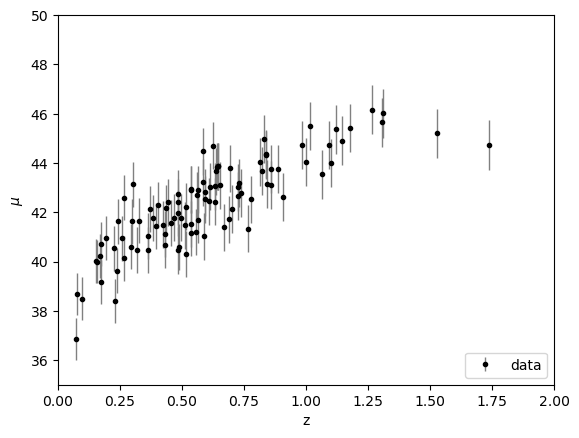

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


Linear fit:  slope = 4.764,  intercept = 39.484


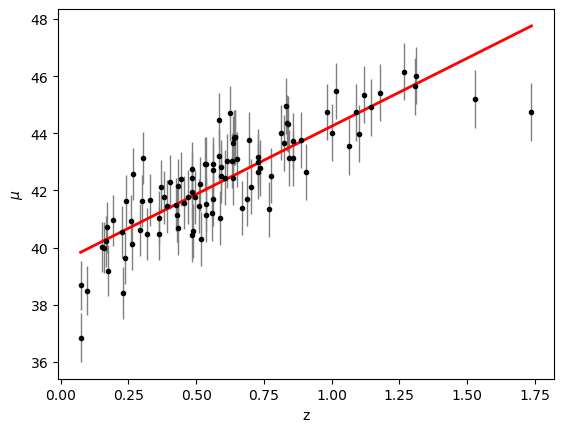

In [2]:
#start with linear regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

x = z_sample[:, np.newaxis]
y = mu_sample

model = LinearRegression()
weights = 1/dmu**2
model.fit(x, y, sample_weight=weights)

theta0 = model.intercept_
theta1 = model.coef_[0]
print(f'Linear fit:  slope = {theta1:.3f},  intercept = {theta0:.3f}')

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = theta1 * x_fit + theta0

plt.figure()
plt.errorbar(x, y, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(x_fit, y_fit, 'r-', lw=2, label=f'Linear fit (d=1)')
plt.xlabel(r'z')
plt.ylabel(r'$\mu$')
plt.show()



c:\Users\user\anaconda3\Lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


[42.38034994]
[39.56505555  4.64711848]
[38.44821027  8.49035585 -2.57760572]
[38.49130243  8.23905057 -2.20391808 -0.15168104]
[ 37.0543994   20.74217865 -32.83020744  27.30599762  -7.98337391]
[ 36.18760445  31.00142053 -69.82397489  82.84185044 -44.24104125
   8.47059008]
[  35.52810145   41.0777603  -119.2923833   190.65950213 -159.23341791
   67.07109508  -11.37900289]
[   33.0388866     88.36455436  -419.10465978  1070.05460078
 -1505.50746677  1174.27289713  -473.67088511    76.75032208]
[  33.50565858   77.89342065 -337.63347914  765.4161251  -882.60407239
  442.01979981   18.73687926  -98.85713123   25.70456796]
[   35.26610351    32.52717373    84.29772055 -1185.19631674
  4221.8203542  -7581.90261829  7725.37966027 -4516.73127761
  1411.3078108   -182.6279746 ]


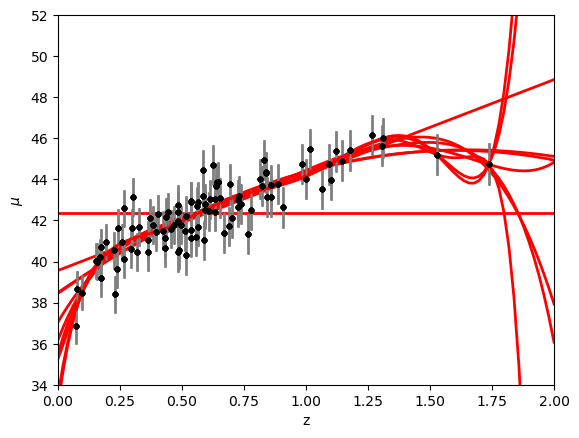

In [3]:
#now lets do the polynomial regression 

from astroML.linear_model import PolynomialRegression

z_test = np.linspace(0, 2, 100)

number_of_degrees = 10 

for i in range(number_of_degrees):
    degree = i
    model = PolynomialRegression(degree) # fit 3rd degree polynomial
    model.fit(z_sample[:, np.newaxis], mu_sample)

    y_pred = model.predict(z_test[:, np.newaxis])
    n_constraints = degree + 1

    print(model.coef_)

    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
    plt.plot(z_test, y_pred, 'r-', lw=2, label=f'Polynomial fit (d={degree})')
    plt.xlabel(r'z')
    plt.ylabel(r'$\mu$')
    plt.ylim(34, 52)
    plt.xlim(0, 2)

plt.show()



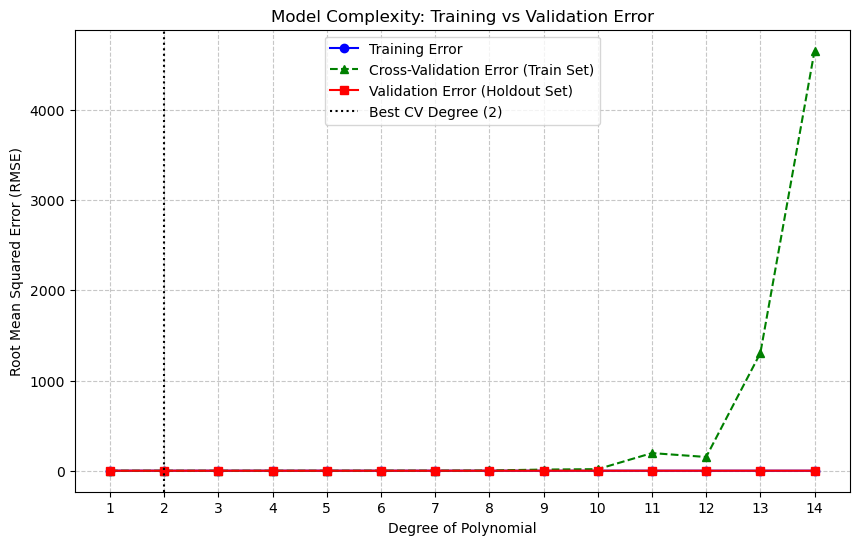

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

train_errors = []
val_errors = []

# Loop over degrees to train models on the FULL training set and evaluate
for i in degrees:
    model = make_pipeline(PolynomialFeatures(i), LinearRegression())
    
    # Train the model on the full training set
    model.fit(X_train, y_train, linearregression__sample_weight=weights_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Calculate RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

# --- Plotting the Learning Curve ---
plt.figure(figsize=(10, 6))

# Plot the three error curves
plt.plot(degrees, train_errors, label='Training Error', marker='o', color='blue')
plt.plot(degrees, cv_score_mean, label='Cross-Validation Error (Train Set)', marker='^', linestyle='--', color='green')
plt.plot(degrees, val_errors, label='Validation Error (Holdout Set)', marker='s', color='red')

# Add a vertical line to highlight the best degree from Cross-Validation
plt.axvline(x=best_degree, color='black', linestyle=':', label=f'Best CV Degree ({best_degree})')

# Labels and formatting
plt.xlabel('Degree of Polynomial')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Model Complexity: Training vs Validation Error')
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# (Optional) Limit the y-axis to make the plot readable since high degrees explode
# plt.ylim(0, np.max(cv_score_mean) * 1.5) 

plt.show()
